# Exploratory Data Analysis: KazSAnDRA Dataset

Explore the KazSAnDRA polarity classification dataset (Kazakh customer reviews).

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from src.data_loader import load_kazsandra

sns.set_theme(style="whitegrid")
print("Imports done.")

Imports done.


## 1. Load Data

In [2]:
splits = load_kazsandra()
train_df = splits["train"]
val_df = splits["val"]
test_df = splits["test"]

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df):,}")
print(f"\nColumns: {list(train_df.columns)}")
print(f"\nDtypes:\n{train_df.dtypes}")
print(f"\nNull counts (train):\n{train_df.isnull().sum()}")
train_df.head()

Train: 134,368  |  Val: 16,796  |  Test: 16,797
Total: 167,961

Columns: ['custom_id', 'text', 'text_cleaned', 'label', 'domain']

Dtypes:
custom_id       object
text            object
text_cleaned    object
label            int64
domain          object
dtype: object

Null counts (train):
custom_id       0
text            0
text_cleaned    0
label           0
domain          0
dtype: int64


,custom_id,text,text_cleaned,label,domain
0,pla015439pla,Өтте күшті,өтте күшті,1,appstore
1,pla083193pla,Мәбазар жок .Оте керемет тамаша керемет,мәбазар жок оте керемет тамаша керемет,1,appstore
2,pla113624pla,"Кушти , дал тура айтады 👍👍👍👍",кушти дал тура айтады,1,appstore
3,pla029825pla,Реклама коп,реклама коп,0,appstore
4,pla002604pla,5-баға беремін,5 баға беремін,1,appstore


## 2. Label Distribution

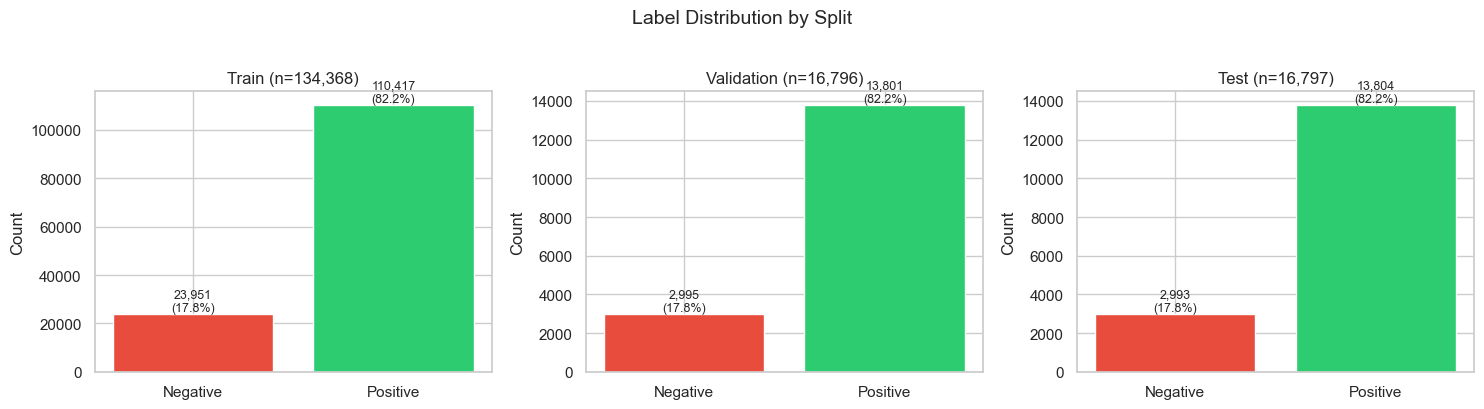

In [3]:
label_map = {0: "Negative", 1: "Positive"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [("Train", train_df), ("Validation", val_df), ("Test", test_df)]):
    counts = df["label"].value_counts().sort_index()
    bars = ax.bar([label_map[i] for i in counts.index], counts.values, color=["#e74c3c", "#2ecc71"])
    ax.set_title(f"{name} (n={len(df):,})")
    ax.set_ylabel("Count")
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:,}\n({v/len(df)*100:.1f}%)",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Label Distribution by Split", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Domain Distribution

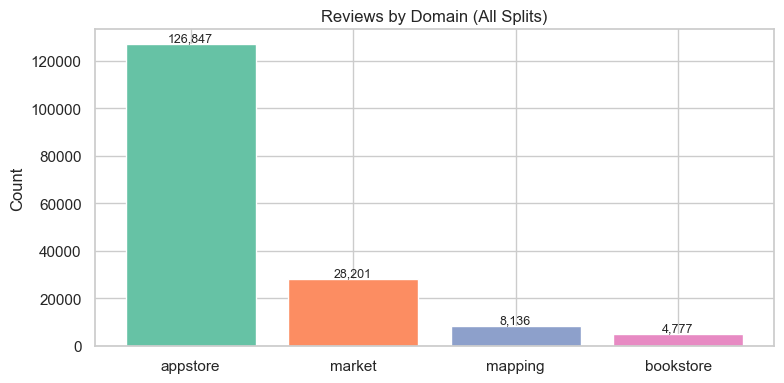

In [4]:
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

domain_counts = all_df["domain"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(domain_counts.index, domain_counts.values, color=sns.color_palette("Set2", len(domain_counts)))
ax.set_title("Reviews by Domain (All Splits)")
ax.set_ylabel("Count")
for bar, v in zip(bars, domain_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 4. Domain × Label Cross-Tab

In [5]:
ct = pd.crosstab(all_df["domain"], all_df["label"].map(label_map), margins=True)
print(ct)

# Percentage
ct_pct = pd.crosstab(all_df["domain"], all_df["label"].map(label_map), normalize="index").round(3) * 100
print("\nPercentage by domain:")
print(ct_pct)

label      Negative  Positive     All
domain                               
appstore      26590    100257  126847
bookstore       763      4014    4777
mapping        1209      6927    8136
market         1377     26824   28201
All           29939    138022  167961

Percentage by domain:
label      Negative  Positive
domain                       
appstore       21.0      79.0
bookstore      16.0      84.0
mapping        14.9      85.1
market          4.9      95.1


## 5. Text Length Analysis

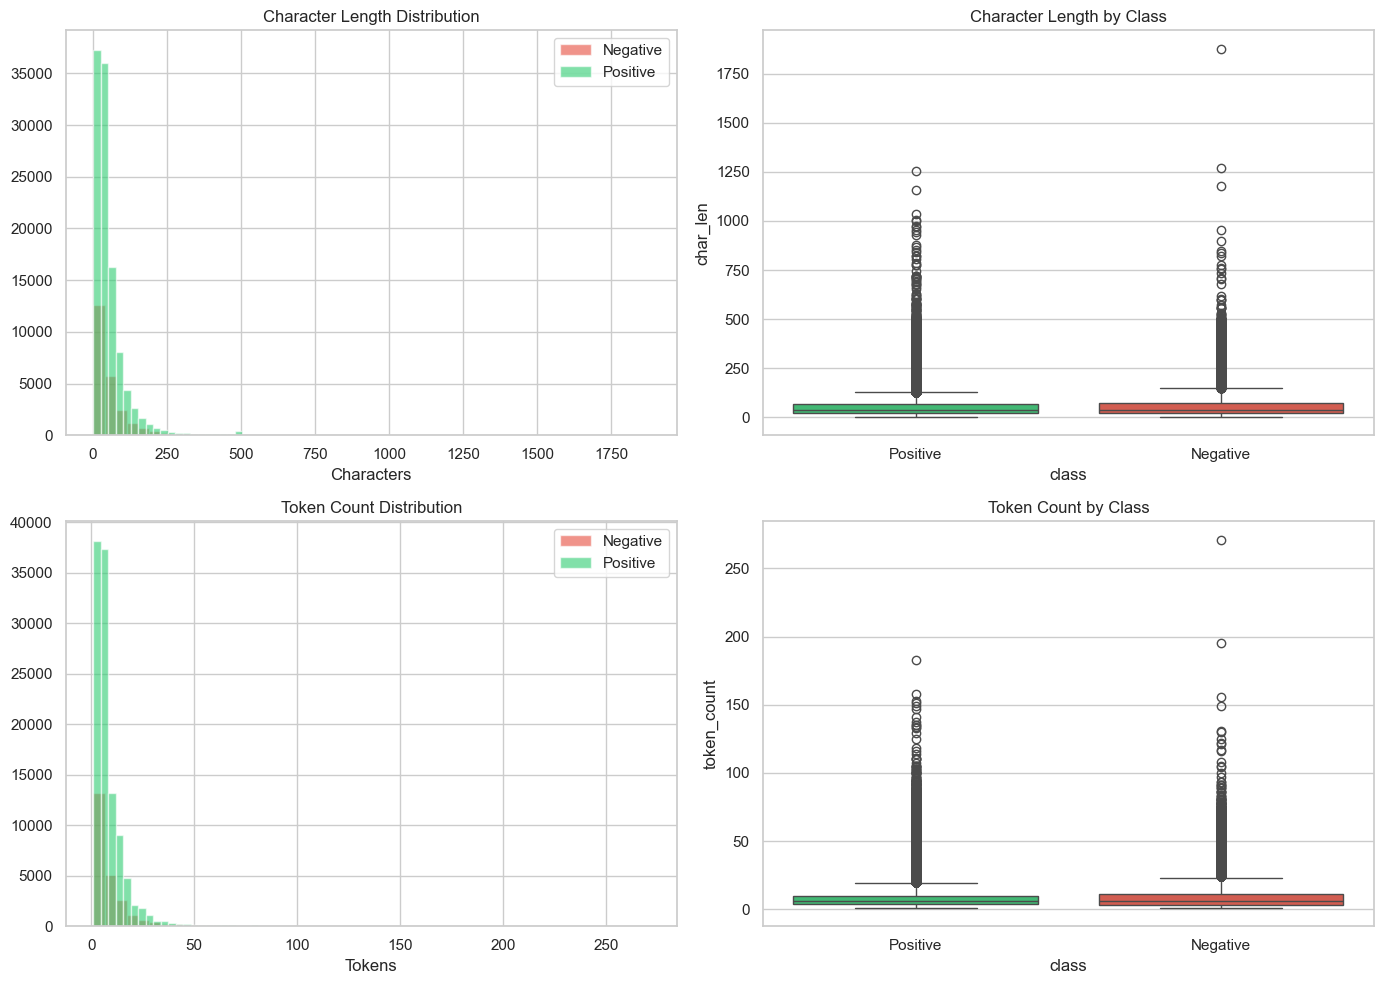


Length statistics by class:
          char_len                                            token_count  \
             count  mean   std  min   25%   50%   75%     max       count   
class                                                                       
Negative   23951.0  62.0  75.2  2.0  20.0  37.0  72.0  1877.0     23951.0   
Positive  110417.0  55.6  61.2  2.0  23.0  37.0  65.0  1257.0    110417.0   

                                                 
         mean   std  min  25%  50%   75%    max  
class                                            
Negative  9.4  11.0  1.0  3.0  6.0  11.0  271.0  
Positive  8.5   9.0  1.0  4.0  6.0  10.0  183.0  


In [6]:
train_df["char_len"] = train_df["text_cleaned"].fillna("").str.len()
train_df["token_count"] = train_df["text_cleaned"].fillna("").str.split().str.len()
train_df["class"] = train_df["label"].map(label_map)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Character length histograms
for cls, color in [("Negative", "#e74c3c"), ("Positive", "#2ecc71")]:
    subset = train_df[train_df["class"] == cls]["char_len"]
    axes[0, 0].hist(subset, bins=50, alpha=0.6, label=cls, color=color)
axes[0, 0].set_title("Character Length Distribution")
axes[0, 0].set_xlabel("Characters")
axes[0, 0].legend()

# Character length boxplot
sns.boxplot(data=train_df, x="class", y="char_len", ax=axes[0, 1],
            palette={"Negative": "#e74c3c", "Positive": "#2ecc71"}, hue="class", legend=False)
axes[0, 1].set_title("Character Length by Class")

# Token count histograms
for cls, color in [("Negative", "#e74c3c"), ("Positive", "#2ecc71")]:
    subset = train_df[train_df["class"] == cls]["token_count"]
    axes[1, 0].hist(subset, bins=50, alpha=0.6, label=cls, color=color)
axes[1, 0].set_title("Token Count Distribution")
axes[1, 0].set_xlabel("Tokens")
axes[1, 0].legend()

# Token count boxplot
sns.boxplot(data=train_df, x="class", y="token_count", ax=axes[1, 1],
            palette={"Negative": "#e74c3c", "Positive": "#2ecc71"}, hue="class", legend=False)
axes[1, 1].set_title("Token Count by Class")

plt.tight_layout()
plt.show()

# Summary stats
print("\nLength statistics by class:")
print(train_df.groupby("class")[["char_len", "token_count"]].describe().round(1))

## 6. Sample Reviews

In [7]:
for label_val, label_name in label_map.items():
    print(f"\n{'='*60}")
    print(f"  {label_name} Reviews (5 random samples)")
    print(f"{'='*60}")
    samples = train_df[train_df["label"] == label_val].sample(5, random_state=42)
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        text = row["text_cleaned"][:200]
        print(f"\n{i}. [{row['domain']}] {text}{'...' if len(row['text_cleaned']) > 200 else ''}")


  Negative Reviews (5 random samples)

1. [appstore] tele 2 өте жақсы бірақ бізде интернет слабый устамайды жай ұстайды

2. [appstore] неге бұрынғы алган заттың кредиттін жаңа кредитке косасыз жаңа алган заттың кредиттін келесі айдан бастап төлеймін неге числосына карай дұрыс жазбайсыз

3. [appstore] адамдардың білімін теріс жаққа бұрмандар көп сұрақтың жауабы дұрыс емес ніл өзені виктория көлінен бастау алады ғабит мүсірепов қазақ әдебиеті газетінің алғашқы бас редакторы т б қателер көп

4. [mapping] іші лас

5. [appstore] менің аккауынтымды забаловироват етіп тастады

  Positive Reviews (5 random samples)

1. [appstore] оте жақсы мен леон түсірдім ура мен қуандым

2. [appstore] неге басылмай жатр далбаёптар адамды алдап

3. [appstore] мыналардың бағасынан басың айналады ғой

4. [appstore] қазақша пернетақта өте ыңғайлы вапче супер

5. [market] жақсы сыйлық


## 7. Language Mixing Analysis

KazSAnDRA contains code-switching: Kazakh Cyrillic, Kazakh Latin, mixed Russian/Kazakh.

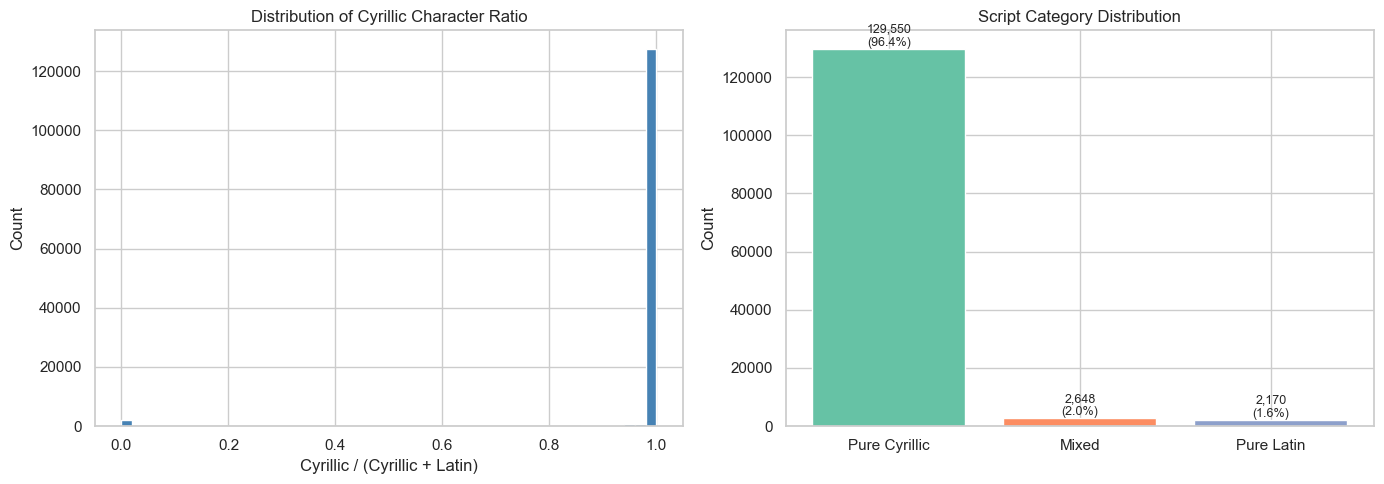

In [8]:
def cyrillic_ratio(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    cyrillic = len(re.findall(r'[\u0400-\u04FF]', text))
    alpha = len(re.findall(r'[a-zA-Z\u0400-\u04FF]', text))
    return cyrillic / alpha if alpha > 0 else 0.0

train_df["cyrillic_ratio"] = train_df["text_cleaned"].apply(cyrillic_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of Cyrillic ratio
axes[0].hist(train_df["cyrillic_ratio"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Cyrillic Character Ratio")
axes[0].set_xlabel("Cyrillic / (Cyrillic + Latin)")
axes[0].set_ylabel("Count")

# Script categories
def script_category(ratio):
    if ratio > 0.9:
        return "Pure Cyrillic"
    elif ratio < 0.1:
        return "Pure Latin"
    else:
        return "Mixed"

train_df["script"] = train_df["cyrillic_ratio"].apply(script_category)
script_counts = train_df["script"].value_counts()
axes[1].bar(script_counts.index, script_counts.values, color=sns.color_palette("Set2", 3))
axes[1].set_title("Script Category Distribution")
axes[1].set_ylabel("Count")
for i, (idx, v) in enumerate(script_counts.items()):
    axes[1].text(i, v, f"{v:,}\n({v/len(train_df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [9]:
summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test", "Total"],
    "Count": [len(train_df), len(val_df), len(test_df), len(all_df)],
    "Positive %": [
        f"{train_df['label'].mean()*100:.1f}%",
        f"{val_df['label'].mean()*100:.1f}%",
        f"{test_df['label'].mean()*100:.1f}%",
        f"{all_df['label'].mean()*100:.1f}%",
    ],
    "Negative %": [
        f"{(1-train_df['label'].mean())*100:.1f}%",
        f"{(1-val_df['label'].mean())*100:.1f}%",
        f"{(1-test_df['label'].mean())*100:.1f}%",
        f"{(1-all_df['label'].mean())*100:.1f}%",
    ],
})
print(summary.to_string(index=False))

print(f"\nDomains: {sorted(all_df['domain'].unique())}")
print(f"Unique domains: {all_df['domain'].nunique()}")

     Split  Count Positive % Negative %
     Train 134368      82.2%      17.8%
Validation  16796      82.2%      17.8%
      Test  16797      82.2%      17.8%
     Total 167961      82.2%      17.8%

Domains: ['appstore', 'bookstore', 'mapping', 'market']
Unique domains: 4


## 9. Key Takeaways

- **Dataset:** ~180K Kazakh customer reviews across 3 domains
- **Task:** Binary polarity classification (positive vs negative)
- **Class balance:** Check output above — likely imbalanced (more positive reviews)
- **Language:** Kazakh with code-switching (Cyrillic, Latin, mixed Russian/Kazakh)
- **Text lengths:** Majority of reviews are short (< 200 characters)
- **Pre-split:** 80/10/10 by authors, preserving domain and label distribution